In [7]:
print("kernel is working")


kernel is working


In [8]:
print("kernel is working")

kernel is working


In [9]:
import pandas as pd
import numpy as np
print("working")

working


In [10]:
import pandas as pd
import numpy as np

print("El Niño project ready 🚀")

El Niño project ready 🚀


In [12]:
import os
print(os.getcwd())

c:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\03_Notebooks


In [2]:
import pandas as pd

oni = pd.read_excel("../01_Data/raw/enso_oni/oni.xlsx")

oni.head()

FileNotFoundError: [Errno 2] No such file or directory: '../01_Data/raw/enso_oni/oni.xlsx'

In [3]:
import os

print(os.getcwd())

c:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\03_Notebooks


In [4]:
import os

print(os.listdir(".."))

['01_Data', '02_Literature_Review', '03_Notebooks', '04_Models', '05_Results', '06_Report', '07_Presentation']


In [5]:
import os

print(os.listdir("../01_Data"))

['External', 'Processed', 'Raw']


In [6]:
print(os.listdir("../01_Data/raw"))

['Agriculture', 'ENSO_ONI', 'Rainfall', 'Temperature', 'Water_Resources']


In [7]:
import os

print(os.listdir("../01_Data/ENSO_ONI"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../01_Data/ENSO_ONI'

In [8]:
import os

for root, dirs, files in os.walk("../01_Data"):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files)
    print("-"*50)

ROOT: ../01_Data
DIRS: ['External', 'Processed', 'Raw']
FILES: []
--------------------------------------------------
ROOT: ../01_Data\External
DIRS: ['Data_Dictionaries', 'References', 'Source_Documents']
FILES: []
--------------------------------------------------
ROOT: ../01_Data\External\Data_Dictionaries
DIRS: []
FILES: []
--------------------------------------------------
ROOT: ../01_Data\External\References
DIRS: []
FILES: []
--------------------------------------------------
ROOT: ../01_Data\External\Source_Documents
DIRS: []
FILES: []
--------------------------------------------------
ROOT: ../01_Data\Processed
DIRS: ['Agriculture', 'ENSO_ONI', 'Merged', 'Rainfall', 'Temperature', 'Water_Resources']
FILES: []
--------------------------------------------------
ROOT: ../01_Data\Processed\Agriculture
DIRS: []
FILES: []
--------------------------------------------------
ROOT: ../01_Data\Processed\ENSO_ONI
DIRS: []
FILES: []
--------------------------------------------------
ROOT: .

In [9]:
import os

for root, dirs, files in os.walk("../01_Data"):
    for file in files:
        if "oni" in file.lower():
            print(os.path.join(root, file))

../01_Data\Raw\ENSO_ONI\oni_raw.xlsx


In [10]:
import pandas as pd

oni = pd.read_excel("../01_Data/Raw/ENSO_ONI/oni_raw.xlsx")

oni.head()

,Year,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
0,1950.0,-1.5,-1.3,-1.2,-1.2,-1.1,-0.9,-0.5,-0.4,-0.4,-0.4,-0.6,-0.8
1,1951.0,-0.8,-0.5,-0.2,0.2,0.4,0.6,0.7,0.9,1,1.2,1,0.8
2,1952.0,0.5,0.4,0.3,0.3,0.2,0,-0.1,0,0.2,0.1,0,0.1
3,1953.0,0.4,0.6,0.6,0.7,0.8,0.8,0.7,0.7,0.8,0.8,0.8,0.8
4,1954.0,0.8,0.5,0,-0.4,-0.5,-0.5,-0.6,-0.8,-0.9,-0.8,-0.7,-0.7


In [11]:
df_melt = oni.melt(
    id_vars=["Year"],
    var_name="Season",
    value_name="ONI"
)

df_melt.head()

,Year,Season,ONI
0,1950.0,DJF,-1.5
1,1951.0,DJF,-0.8
2,1952.0,DJF,0.5
3,1953.0,DJF,0.4
4,1954.0,DJF,0.8


In [12]:
df_melt.info()

<class 'pandas.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    924 non-null    float64
 1   Season  936 non-null    str    
 2   ONI     928 non-null    object 
dtypes: float64(1), object(1), str(1)
memory usage: 22.1+ KB


In [13]:
df_melt["ONI"] = pd.to_numeric(df_melt["ONI"], errors="coerce")

df_melt.info()

<class 'pandas.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    924 non-null    float64
 1   Season  936 non-null    str    
 2   ONI     916 non-null    float64
dtypes: float64(2), str(1)
memory usage: 22.1 KB


In [14]:
print(df_melt.isnull().sum())

Year      12
Season     0
ONI       20
dtype: int64


In [15]:
df_melt = df_melt.dropna()

df_melt.info()

<class 'pandas.DataFrame'>
Index: 916 entries, 0 to 934
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    916 non-null    float64
 1   Season  916 non-null    str    
 2   ONI     916 non-null    float64
dtypes: float64(2), str(1)
memory usage: 28.6 KB


In [16]:
def classify_enso(x):
    if x >= 0.5:
        return "El Nino"
    elif x <= -0.5:
        return "La Nina"
    else:
        return "Neutral"

df_melt["ENSO_Phase"] = df_melt["ONI"].apply(classify_enso)

print(df_melt["ENSO_Phase"].value_counts())

ENSO_Phase
Neutral    391
La Nina    266
El Nino    259
Name: count, dtype: int64


In [18]:
df_melt.to_csv(
    "../01_Data/Processed/ENSO_ONI/oni_cleaned.csv",
    index=False
)

In [19]:
import os

for root, dirs, files in os.walk("../01_Data/Raw/Rainfall"):
    print(root)
    print(files)
    print("-"*50)

../01_Data/Raw/Rainfall
[]
--------------------------------------------------
../01_Data/Raw/Rainfall\metadata
[]
--------------------------------------------------


In [20]:
import pandas as pd

rainfall = pd.read_csv("../01_Data/Raw/Rainfall/india_rainfall_raw.csv")

print("Shape:", rainfall.shape)
rainfall.head()

Shape: (116, 11)


,YEAR,Actual Rainfall: JUN,Actual Rainfall: JUL,Actual Rainfall: AUG,Actual Rainfall: SEPT,Actual Rainfall: JUN-SEPT,Departure Percentage: JUN,Departure Percentage: JUL,Departure Percentage: AUG,Departure Percentage: SEP,Departure Percentage: JUN-SEPT
0,1901,109.1,241.4,284.2,121.9,756.6,-29.9,-16.7,11.0,-28.4,-13.1
1,1902,104.0,283.7,202.6,201.9,792.1,-33.6,-2.0,-21.0,18.7,-9.1
2,1903,114.8,293.0,279.6,204.4,891.9,-26.6,1.6,9.6,20.3,2.6
3,1904,158.8,266.4,210.4,129.6,765.2,2.8,-7.7,-17.4,-23.8,-11.8
4,1905,88.7,252.5,202.6,174.6,718.5,-43.6,-12.3,-21.2,3.2,-17.4


In [21]:
rainfall.info()

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   YEAR                            116 non-null    int64  
 1   Actual Rainfall: JUN            116 non-null    float64
 2   Actual Rainfall: JUL            116 non-null    float64
 3   Actual Rainfall: AUG            116 non-null    float64
 4   Actual Rainfall: SEPT           116 non-null    float64
 5   Actual Rainfall: JUN-SEPT       116 non-null    float64
 6   Departure Percentage: JUN       116 non-null    float64
 7   Departure Percentage: JUL       116 non-null    float64
 8   Departure Percentage: AUG       116 non-null    float64
 9   Departure Percentage: SEP       116 non-null    float64
 10  Departure Percentage: JUN-SEPT  116 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 10.1 KB


In [22]:
rainfall.shape

(116, 11)

In [23]:
rainfall_clean = rainfall[[
    "YEAR",
    "Actual Rainfall: JUN-SEPT",
    "Departure Percentage: JUN-SEPT"
]].copy()

rainfall_clean.columns = [
    "Year",
    "Monsoon_Rainfall",
    "Rainfall_Departure"
]

rainfall_clean.head()

,Year,Monsoon_Rainfall,Rainfall_Departure
0,1901,756.6,-13.1
1,1902,792.1,-9.1
2,1903,891.9,2.6
3,1904,765.2,-11.8
4,1905,718.5,-17.4


In [24]:
rainfall_clean.to_csv(
    "../01_Data/Processed/Rainfall/rainfall_cleaned.csv",
    index=False
)

In [25]:
oni_yearly = (
    df_melt.groupby("Year")["ONI"]
    .mean()
    .reset_index()
)

oni_yearly["Year"] = oni_yearly["Year"].astype(int)

oni_yearly.head()

,Year,ONI
0,1950,-0.858333
1,1951,0.441667
2,1952,0.166667
3,1953,0.708333
4,1954,-0.383333


In [26]:
merged = pd.merge(
    oni_yearly,
    rainfall_clean,
    on="Year",
    how="inner"
)

print(merged.shape)

merged.head()

(67, 4)


,Year,ONI,Monsoon_Rainfall,Rainfall_Departure
0,1950,-0.858333,923.2,3.7
1,1951,0.441667,749.2,-18.7
2,1952,0.166667,827.8,-8.2
3,1953,0.708333,983.4,9.8
4,1954,-0.383333,914.4,3.1


In [27]:
print("Merged Shape:", merged.shape)

Merged Shape: (67, 4)


In [28]:
correlation = merged["ONI"].corr(
    merged["Monsoon_Rainfall"]
)

print("Correlation:", correlation)


Correlation: -0.3487953772571016


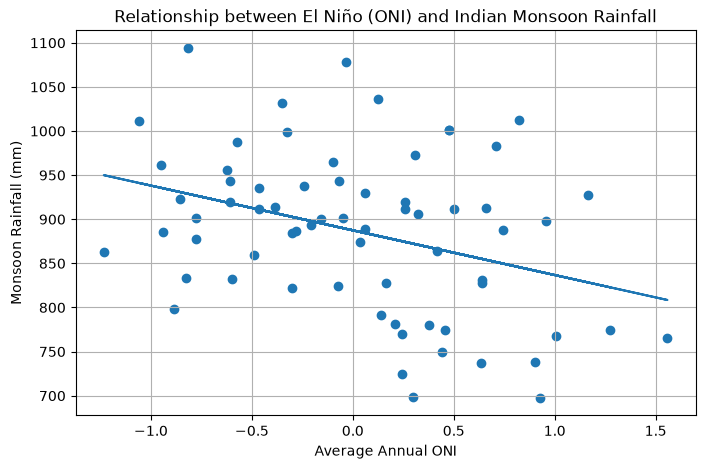

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    merged["ONI"],
    merged["Monsoon_Rainfall"]
)

z = np.polyfit(
    merged["ONI"],
    merged["Monsoon_Rainfall"],
    1
)

p = np.poly1d(z)

plt.plot(
    merged["ONI"],
    p(merged["ONI"])
)

plt.xlabel("Average Annual ONI")
plt.ylabel("Monsoon Rainfall (mm)")
plt.title("Relationship between El Niño (ONI) and Indian Monsoon Rainfall")
plt.grid(True)

plt.show()

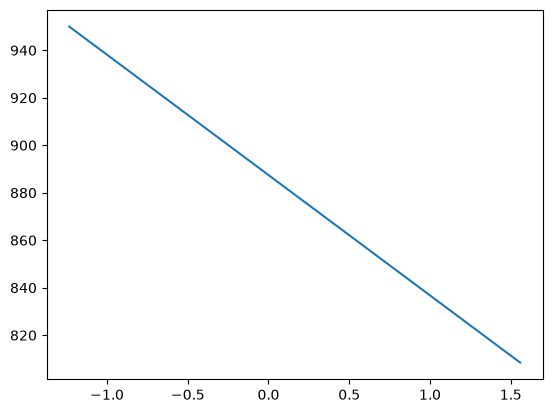

In [32]:
merged_sorted = merged.sort_values("ONI")

plt.plot(
    merged_sorted["ONI"],
    p(merged_sorted["ONI"])
)

In [33]:
import os

base_path = "../01_Data/Raw"

rename_map = {
    "Agriculutre": "Agriculture",   # fixes typo if present
    "agriculture": "Agriculture",
    "rainfall": "Rainfall",
    "water_resources": "Water_Resources",
    "temperature": "Temperature",
    "enso_oni": "ENSO_ONI"
}

for old_name, new_name in rename_map.items():
    old_path = os.path.join(base_path, old_name)
    new_path = os.path.join(base_path, new_name)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {old_name} -> {new_name}")

print("Done!")

Renamed: agriculture -> Agriculture
Renamed: rainfall -> Rainfall
Renamed: water_resources -> Water_Resources
Renamed: temperature -> Temperature
Renamed: enso_oni -> ENSO_ONI
Done!


In [34]:
import os

print(os.listdir("../01_Data/Raw"))

['Agriculture', 'ENSO_ONI', 'Rainfall', 'Temperature', 'Water_Resources']


In [35]:
import os

for dataset in ["Temperature", "Agriculture", "Water_Resources"]:
    print(f"\n===== {dataset} =====")

    path = f"../01_Data/Raw/{dataset}"

    for root, dirs, files in os.walk(path):
        print("ROOT:", root)
        print("FILES:", files)
        print("-"*50)


===== Temperature =====
ROOT: ../01_Data/Raw/Temperature
FILES: []
--------------------------------------------------
ROOT: ../01_Data/Raw/Temperature\metadata
FILES: []
--------------------------------------------------

===== Agriculture =====
ROOT: ../01_Data/Raw/Agriculture
FILES: []
--------------------------------------------------
ROOT: ../01_Data/Raw/Agriculture\metadata
FILES: []
--------------------------------------------------

===== Water_Resources =====
ROOT: ../01_Data/Raw/Water_Resources
FILES: []
--------------------------------------------------
ROOT: ../01_Data/Raw/Water_Resources\metadata
FILES: []
--------------------------------------------------


In [36]:
import os

for folder in ["Temperature", "Agriculture", "Water_Resources"]:
    print("\n", folder)
    path = f"../01_Data/Raw/{folder}"
    print(os.listdir(path))


 Temperature
['GlobalLandTemperaturesByCity.csv', 'GlobalLandTemperaturesByCountry.csv', 'GlobalLandTemperaturesByMajorCity.csv', 'GlobalLandTemperaturesByState.csv', 'GlobalTemperatures.csv', 'metadata']

 Agriculture
['Indian_crop_production_yield_dataset.csv', 'metadata']

 Water_Resources
['Daily_data_of_reservoir_level_of_Central_Water_Commission_(CWC)_Agency_during_March_2024.csv', 'metadata']


In [37]:
import os

# Delete unwanted temperature files
delete_files = [
    "../01_Data/Raw/Temperature/GlobalLandTemperaturesByCity.csv",
    "../01_Data/Raw/Temperature/GlobalLandTemperaturesByMajorCity.csv",
    "../01_Data/Raw/Temperature/GlobalLandTemperaturesByState.csv",
    "../01_Data/Raw/Temperature/GlobalTemperatures.csv"
]

for file in delete_files:
    if os.path.exists(file):
        os.remove(file)
        print("Deleted:", file)


# Rename remaining useful files
rename_files = {
    "../01_Data/Raw/Temperature/GlobalLandTemperaturesByCountry.csv":
    "../01_Data/Raw/Temperature/temperature_raw.csv",

    "../01_Data/Raw/Agriculture/Indian_crop_production_yield_dataset.csv":
    "../01_Data/Raw/Agriculture/agriculture_raw.csv",

    "../01_Data/Raw/Water_Resources/Daily_data_of_reservoir_level_of_Central_Water_Commission_(CWC)_Agency_during_March_2024.csv":
    "../01_Data/Raw/Water_Resources/water_resources_raw.csv"
}

for old, new in rename_files.items():
    if os.path.exists(old):
        os.rename(old, new)
        print("Renamed:", new)

print("Cleanup complete!")

Deleted: ../01_Data/Raw/Temperature/GlobalLandTemperaturesByCity.csv
Deleted: ../01_Data/Raw/Temperature/GlobalLandTemperaturesByMajorCity.csv
Deleted: ../01_Data/Raw/Temperature/GlobalLandTemperaturesByState.csv
Deleted: ../01_Data/Raw/Temperature/GlobalTemperatures.csv
Renamed: ../01_Data/Raw/Temperature/temperature_raw.csv
Renamed: ../01_Data/Raw/Agriculture/agriculture_raw.csv
Renamed: ../01_Data/Raw/Water_Resources/water_resources_raw.csv
Cleanup complete!


In [38]:
import os

for folder in ["Temperature", "Agriculture", "Water_Resources"]:
    print("\n", folder)
    print(os.listdir(f"../01_Data/Raw/{folder}"))


 Temperature
['metadata', 'temperature_raw.csv']

 Agriculture
['agriculture_raw.csv', 'metadata']

 Water_Resources
['metadata', 'water_resources_raw.csv']


In [39]:
import pandas as pd

temperature = pd.read_csv(
    "../01_Data/Raw/Temperature/temperature_raw.csv"
)

print("Shape:", temperature.shape)

temperature.head()

Shape: (577462, 4)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [40]:
temperature.info()

<class 'pandas.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  str    
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  str    
dtypes: float64(2), str(2)
memory usage: 17.6 MB


In [41]:
temperature["Country"].unique()[:20]

<StringArray>
[              'Åland',         'Afghanistan',              'Africa',
             'Albania',             'Algeria',      'American Samoa',
             'Andorra',              'Angola',            'Anguilla',
          'Antarctica', 'Antigua And Barbuda',           'Argentina',
             'Armenia',               'Aruba',                'Asia',
           'Australia',             'Austria',          'Azerbaijan',
             'Bahamas',             'Bahrain']
Length: 20, dtype: str

In [42]:
"India" in temperature["Country"].unique()

True

In [43]:
india_temp = temperature[
    temperature["Country"] == "India"
].copy()

print(india_temp.shape)

india_temp.head()

(2613, 4)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
243695,1796-01-01,17.044,2.044,India
243696,1796-02-01,19.193,1.359,India
243697,1796-03-01,22.319,2.125,India
243698,1796-04-01,27.233,1.510,India
243699,1796-05-01,30.035,1.338,India


In [44]:
india_temp["dt"] = pd.to_datetime(india_temp["dt"])

india_temp["Year"] = india_temp["dt"].dt.year

india_temp.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year
243695,1796-01-01,17.044,2.044,India,1796
243696,1796-02-01,19.193,1.359,India,1796
243697,1796-03-01,22.319,2.125,India,1796
243698,1796-04-01,27.233,1.510,India,1796
243699,1796-05-01,30.035,1.338,India,1796


In [45]:
india_temp = india_temp.dropna(
    subset=["AverageTemperature"]
)

print(india_temp.shape)

(2508, 5)


In [46]:
temperature_clean = (
    india_temp
    .groupby("Year")["AverageTemperature"]
    .mean()
    .reset_index()
)

temperature_clean.columns = [
    "Year",
    "Avg_Temperature"
]

temperature_clean.head()

,Year,Avg_Temperature
0,1796,23.675250
1,1797,24.839900
2,1798,23.273300
3,1799,23.949417
4,1800,23.911917


In [47]:
print(temperature_clean.shape)
temperature_clean.tail()

(211, 2)


,Year,Avg_Temperature
206,2009,25.146667
207,2010,25.050833
208,2011,24.415583
209,2012,24.640833
210,2013,25.413250


In [48]:
import os

os.makedirs("../01_Data/Processed/Temperature", exist_ok=True)

temperature_clean.to_csv(
    "../01_Data/Processed/Temperature/temperature_cleaned.csv",
    index=False
)

print("Temperature dataset saved!")

Temperature dataset saved!


In [49]:
temperature_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             211 non-null    int32  
 1   Avg_Temperature  211 non-null    float64
dtypes: float64(1), int32(1)
memory usage: 2.6 KB


In [50]:
import pandas as pd

agriculture = pd.read_csv(
    "../01_Data/Raw/Agriculture/agriculture_raw.csv"
)

print("Shape:", agriculture.shape)

agriculture.head()

Shape: (575879, 8)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


In [51]:
agriculture.info()

<class 'pandas.DataFrame'>
RangeIndex: 575879 entries, 0 to 575878
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     575879 non-null  str    
 1   District_Name  575879 non-null  str    
 2   Crop_Year      575879 non-null  int64  
 3   Season         575879 non-null  str    
 4   Crop           575879 non-null  str    
 5   Area           575879 non-null  float64
 6   Production     575879 non-null  float64
 7   yield          575879 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 35.1 MB


In [52]:
agriculture = agriculture.rename(
    columns={"Crop_Year": "Year"}
)

agriculture.head()

,State_Name,District_Name,Year,Season,Crop,Area,Production,yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


In [53]:
agriculture_clean = (
    agriculture
    .groupby("Year")
    .agg({
        "Production": "sum",
        "yield": "mean"
    })
    .reset_index()
)

agriculture_clean.columns = [
    "Year",
    "Total_Production",
    "Avg_Yield"
]

agriculture_clean.head()

,Year,Total_Production,Avg_Yield
0,1997,6.113605e+11,2761.115479
1,1998,7.945267e+11,2711.434640
2,1999,8.630954e+11,2796.409228
3,2000,9.740388e+11,3261.653333
4,2001,9.498138e+11,3313.039293


In [54]:
print(agriculture_clean.shape)

agriculture_clean.info()

(24, 3)
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              24 non-null     int64  
 1   Total_Production  24 non-null     float64
 2   Avg_Yield         24 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 708.0 bytes


In [55]:
agriculture_clean["Year"].tolist()

[1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020]

In [56]:
import os

os.makedirs(
    "../01_Data/Processed/Agriculture",
    exist_ok=True
)

agriculture_clean.to_csv(
    "../01_Data/Processed/Agriculture/agriculture_cleaned.csv",
    index=False
)

print("Agriculture dataset saved!")

Agriculture dataset saved!


In [57]:
water = pd.read_csv(
    "../01_Data/Raw/Water_Resources/water_resources_raw.csv"
)

print(water.shape)

water.head()

(3689, 13)


,Reservoir_name,Basin,Subbasin,Agency_name,Lat,Long,Date,Year,Month,Full_reservoir_level,Live_capacity_FRL,Storage,Level
0,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-01,2024,3,320.04,0.095,0.00810,303.505
1,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-02,2024,3,320.04,0.095,0.00755,303.352
2,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-03,2024,3,320.04,0.095,NaN,NaN
3,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-04,2024,3,320.04,0.095,0.00669,303.093
4,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-05,2024,3,320.04,0.095,0.00621,302.941


In [58]:
water.info()

<class 'pandas.DataFrame'>
RangeIndex: 3689 entries, 0 to 3688
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Reservoir_name        3689 non-null   str    
 1   Basin                 3689 non-null   str    
 2   Subbasin              3689 non-null   str    
 3   Agency_name           3689 non-null   str    
 4   Lat                   3689 non-null   float64
 5   Long                  3689 non-null   float64
 6   Date                  3689 non-null   str    
 7   Year                  3689 non-null   int64  
 8   Month                 3689 non-null   int64  
 9   Full_reservoir_level  3689 non-null   float64
 10  Live_capacity_FRL     3689 non-null   float64
 11  Storage               2578 non-null   float64
 12  Level                 2596 non-null   float64
dtypes: float64(6), int64(2), str(5)
memory usage: 374.8 KB


In [59]:
water["Year"].unique()

array([2024])

In [60]:
water["Year"].min(), water["Year"].max()

(np.int64(2024), np.int64(2024))

In [61]:
print(water["Year"].min())
print(water["Year"].max())
print(water["Year"].nunique())

2024
2024
1


In [62]:
import os

os.makedirs(
    "../01_Data/Processed/Water_Resources",
    exist_ok=True
)

water.to_csv(
    "../01_Data/Processed/Water_Resources/water_resources_cleaned.csv",
    index=False
)

print("Water Resources dataset saved!")

Water Resources dataset saved!


In [63]:
# Final ML Dataset Creation

import pandas as pd

oni = pd.read_csv(
    "../01_Data/Processed/ENSO_ONI/oni_cleaned.csv"
)

rainfall = pd.read_csv(
    "../01_Data/Processed/Rainfall/rainfall_cleaned.csv"
)

temperature = pd.read_csv(
    "../01_Data/Processed/Temperature/temperature_cleaned.csv"
)

print("ONI:", oni.shape)
print("Rainfall:", rainfall.shape)
print("Temperature:", temperature.shape)

ONI: (916, 4)
Rainfall: (116, 3)
Temperature: (211, 2)


In [64]:
oni.head(), rainfall.head(), temperature.head()

(     Year Season  ONI ENSO_Phase
 0  1950.0    DJF -1.5    La Nina
 1  1951.0    DJF -0.8    La Nina
 2  1952.0    DJF  0.5    El Nino
 3  1953.0    DJF  0.4    Neutral
 4  1954.0    DJF  0.8    El Nino,
    Year  Monsoon_Rainfall  Rainfall_Departure
 0  1901             756.6               -13.1
 1  1902             792.1                -9.1
 2  1903             891.9                 2.6
 3  1904             765.2               -11.8
 4  1905             718.5               -17.4,
    Year  Avg_Temperature
 0  1796        23.675250
 1  1797        24.839900
 2  1798        23.273300
 3  1799        23.949417
 4  1800        23.911917)

In [65]:
merged_ml = pd.merge(
    oni,
    rainfall,
    on="Year",
    how="inner"
)

print(merged_ml.shape)

merged_ml.head()

(804, 6)


,Year,Season,ONI,ENSO_Phase,Monsoon_Rainfall,Rainfall_Departure
0,1950.0,DJF,-1.5,La Nina,923.2,3.7
1,1951.0,DJF,-0.8,La Nina,749.2,-18.7
2,1952.0,DJF,0.5,El Nino,827.8,-8.2
3,1953.0,DJF,0.4,Neutral,983.4,9.8
4,1954.0,DJF,0.8,El Nino,914.4,3.1


In [66]:
merged_ml = pd.merge(
    merged_ml,
    temperature,
    on="Year",
    how="inner"
)

print("Final Shape:", merged_ml.shape)

merged_ml.head()

Final Shape: (768, 7)


,Year,Season,ONI,ENSO_Phase,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
0,1950.0,DJF,-1.5,La Nina,923.2,3.7,23.659333
1,1951.0,DJF,-0.8,La Nina,749.2,-18.7,24.220667
2,1952.0,DJF,0.5,El Nino,827.8,-8.2,24.365500
3,1953.0,DJF,0.4,Neutral,983.4,9.8,24.561583
4,1954.0,DJF,0.8,El Nino,914.4,3.1,24.167167


In [67]:
merged_ml.isnull().sum()

Year                  0
Season                0
ONI                   0
ENSO_Phase            0
Monsoon_Rainfall      0
Rainfall_Departure    0
Avg_Temperature       0
dtype: int64

In [68]:
import os

os.makedirs(
    "../01_Data/Processed/Merged",
    exist_ok=True
)

merged_ml.to_csv(
    "../01_Data/Processed/Merged/final_ml_dataset.csv",
    index=False
)

print("Final ML dataset saved!")

Final ML dataset saved!


In [69]:
merged_ml.shape

(768, 7)

In [70]:
merged_ml.head()

,Year,Season,ONI,ENSO_Phase,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
0,1950.0,DJF,-1.5,La Nina,923.2,3.7,23.659333
1,1951.0,DJF,-0.8,La Nina,749.2,-18.7,24.220667
2,1952.0,DJF,0.5,El Nino,827.8,-8.2,24.365500
3,1953.0,DJF,0.4,Neutral,983.4,9.8,24.561583
4,1954.0,DJF,0.8,El Nino,914.4,3.1,24.167167


In [71]:
oni_yearly = (
    oni
    .groupby("Year")
    .agg({
        "ONI": "mean"
    })
    .reset_index()
)

oni_yearly.head()

,Year,ONI
0,1950.0,-0.858333
1,1951.0,0.441667
2,1952.0,0.166667
3,1953.0,0.708333
4,1954.0,-0.383333


In [72]:
merged_ml = pd.merge(
    oni_yearly,
    rainfall,
    on="Year",
    how="inner"
)

merged_ml = pd.merge(
    merged_ml,
    temperature,
    on="Year",
    how="inner"
)

print("Final Shape:", merged_ml.shape)

merged_ml.head()

Final Shape: (64, 5)


,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
0,1950.0,-0.858333,923.2,3.7,23.659333
1,1951.0,0.441667,749.2,-18.7,24.220667
2,1952.0,0.166667,827.8,-8.2,24.365500
3,1953.0,0.708333,983.4,9.8,24.561583
4,1954.0,-0.383333,914.4,3.1,24.167167


In [73]:
merged_ml.to_csv(
    "../01_Data/Processed/Merged/final_ml_dataset.csv",
    index=False
)

print("Correct ML dataset saved!")

Correct ML dataset saved!


In [74]:
merged_ml.shape

(64, 5)

In [75]:
merged_ml.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
0,1950.0,-0.858333,923.2,3.7,23.659333
1,1951.0,0.441667,749.2,-18.7,24.220667
2,1952.0,0.166667,827.8,-8.2,24.365500
3,1953.0,0.708333,983.4,9.8,24.561583
4,1954.0,-0.383333,914.4,3.1,24.167167


In [76]:
merged_ml.to_csv(
    "../01_Data/Processed/Merged/final_ml_dataset.csv",
    index=False
)

print("Final ML dataset saved!")

Final ML dataset saved!


In [77]:
merged_ml.describe()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
count,64.000000,64.000000,64.000000,64.000000,64.000000
mean,1981.500000,-0.001693,889.743750,-0.926562,24.342012
std,18.618987,0.612281,91.421108,10.503820,0.346788
min,1950.000000,-1.233333,697.400000,-23.900000,23.634000
25%,1965.750000,-0.472917,828.175000,-7.800000,24.094542
50%,1981.500000,0.000000,900.800000,0.150000,24.295458
75%,1997.250000,0.462500,943.025000,5.625000,24.566667
max,2013.000000,1.275000,1094.100000,21.800000,25.413250


In [78]:
merged_ml.corr(numeric_only=True)

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
Year,1.000000,-0.100094,-0.184597,-0.171712,0.634636
ONI,-0.100094,1.000000,-0.314353,-0.371198,0.121898
Monsoon_Rainfall,-0.184597,-0.314353,1.000000,0.982301,-0.227359
Rainfall_Departure,-0.171712,-0.371198,0.982301,1.000000,-0.259609
Avg_Temperature,0.634636,0.121898,-0.227359,-0.259609,1.000000


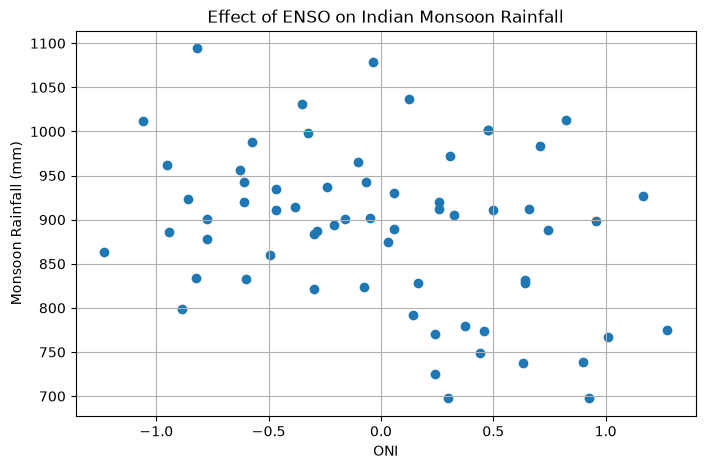

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    merged_ml["ONI"],
    merged_ml["Monsoon_Rainfall"]
)

plt.xlabel("ONI")
plt.ylabel("Monsoon Rainfall (mm)")
plt.title("Effect of ENSO on Indian Monsoon Rainfall")

plt.grid(True)
plt.show()

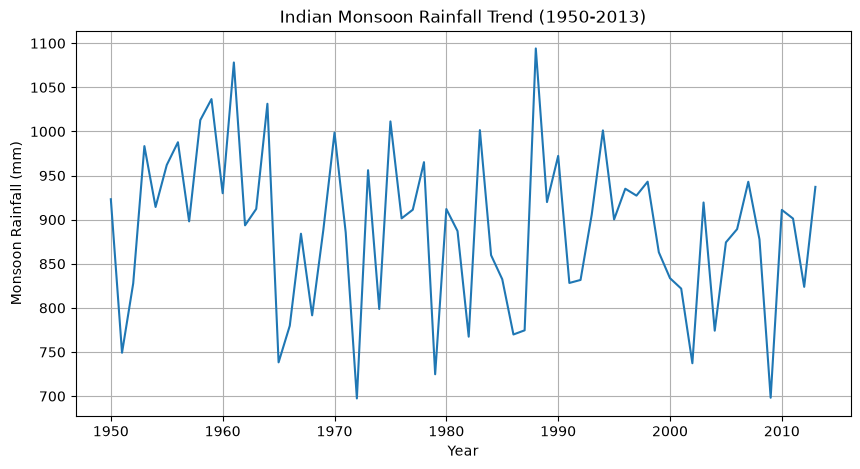

In [80]:
plt.figure(figsize=(10,5))

plt.plot(
    merged_ml["Year"],
    merged_ml["Monsoon_Rainfall"]
)

plt.xlabel("Year")
plt.ylabel("Monsoon Rainfall (mm)")
plt.title("Indian Monsoon Rainfall Trend (1950-2013)")

plt.grid(True)
plt.show()

In [81]:
ml_data = merged_ml[
    ["Year", "ONI", "Avg_Temperature", "Monsoon_Rainfall"]
]

ml_data.head()

,Year,ONI,Avg_Temperature,Monsoon_Rainfall
0,1950.0,-0.858333,23.659333,923.2
1,1951.0,0.441667,24.220667,749.2
2,1952.0,0.166667,24.365500,827.8
3,1953.0,0.708333,24.561583,983.4
4,1954.0,-0.383333,24.167167,914.4


In [82]:
ml_data.shape

(64, 4)

In [83]:
ml_data = merged_ml[
    ["Year", "ONI", "Avg_Temperature", "Monsoon_Rainfall"]
]

ml_data.head()

,Year,ONI,Avg_Temperature,Monsoon_Rainfall
0,1950.0,-0.858333,23.659333,923.2
1,1951.0,0.441667,24.220667,749.2
2,1952.0,0.166667,24.365500,827.8
3,1953.0,0.708333,24.561583,983.4
4,1954.0,-0.383333,24.167167,914.4


In [84]:
ml_data.shape

(64, 4)

In [85]:
X = ml_data[
    ["ONI", "Avg_Temperature"]
]

y = ml_data[
    "Monsoon_Rainfall"
]

print(X.shape)
print(y.shape)

(64, 2)
(64,)


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(51, 2)
(13, 2)


In [88]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

print("Model trained!")

Model trained!


In [89]:
y_pred_lr = lr_model.predict(
    X_test
)

y_pred_lr[:5]

array([839.56243269, 920.28472759, 952.21449343, 869.83939478,
       945.12332848])

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)


print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 67.59110644714556
RMSE: 81.38120999580941
R2 Score: 0.21162388490595152


In [91]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained!")

Random Forest trained!


In [92]:
y_pred_rf = rf_model.predict(
    X_test
)

In [93]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)


print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 82.24569230769234
RMSE: 100.42814865977944
R2 Score: -0.20059377241583443


In [94]:
X2 = ml_data[
    ["Year", "ONI", "Avg_Temperature"]
]

y2 = ml_data["Monsoon_Rainfall"]


X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [95]:
lr_model2 = LinearRegression()

lr_model2.fit(
    X_train2,
    y_train2
)

y_pred_lr2 = lr_model2.predict(
    X_test2
)

In [96]:
mae_lr2 = mean_absolute_error(y_test2, y_pred_lr2)

rmse_lr2 = np.sqrt(
    mean_squared_error(y_test2, y_pred_lr2)
)

r2_lr2 = r2_score(
    y_test2, 
    y_pred_lr2
)

print("MAE:", mae_lr2)
print("RMSE:", rmse_lr2)
print("R2:", r2_lr2)

MAE: 68.22801206945081
RMSE: 83.11360238482922
R2: 0.17770171335667284


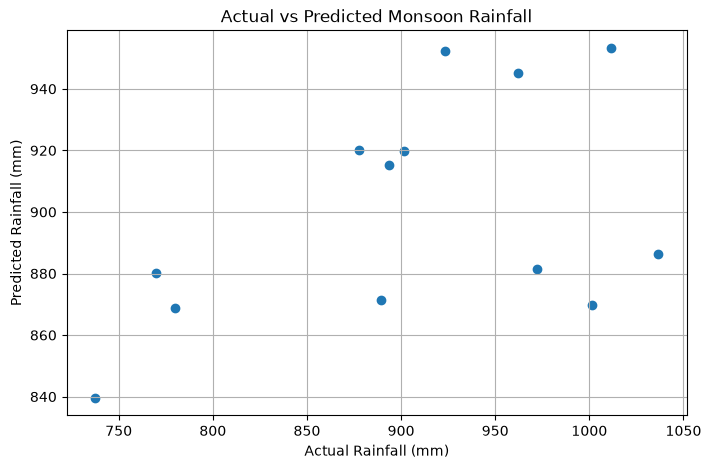

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_lr
)

plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("Actual vs Predicted Monsoon Rainfall")

plt.grid(True)
plt.show()

In [98]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

results.head()

,Actual,Predicted
0,737.3,839.562433
1,877.7,920.284728
2,923.2,952.214493
3,1001.2,869.839395
4,962.0,945.123328


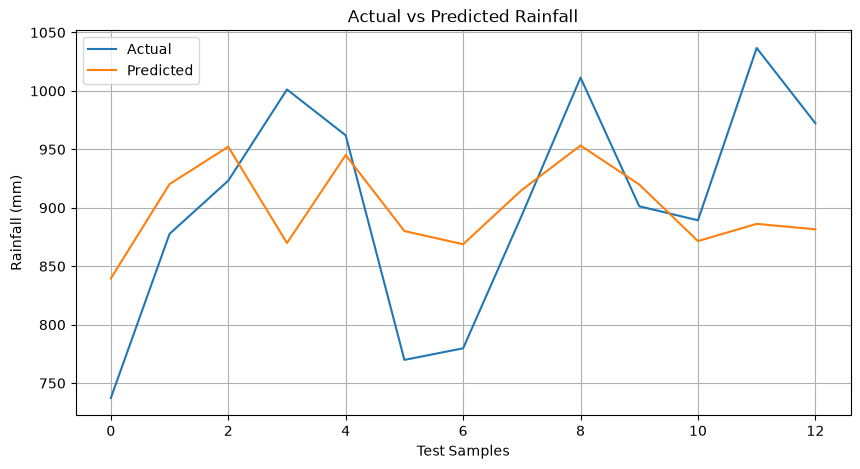

In [99]:
plt.figure(figsize=(10,5))

plt.plot(
    results["Actual"].values,
    label="Actual"
)

plt.plot(
    results["Predicted"].values,
    label="Predicted"
)

plt.xlabel("Test Samples")
plt.ylabel("Rainfall (mm)")
plt.title("Actual vs Predicted Rainfall")

plt.legend()
plt.grid(True)

plt.show()

In [100]:
import pickle

with open(
    "../04_Models/linear_regression_rainfall_model.pkl",
    "wb"
) as file:
    pickle.dump(
        lr_model,
        file
    )

print("Model saved!")

Model saved!


In [101]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Linear Regression + Year"
    ],
    "MAE": [
        67.59,
        82.25,
        68.23
    ],
    "RMSE": [
        81.38,
        100.43,
        83.11
    ],
    "R2": [
        0.212,
        -0.201,
        0.178
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,67.59,81.38,0.212
1,Random Forest,82.25,100.43,-0.201
2,Linear Regression + Year,68.23,83.11,0.178


In [102]:
model_results.to_csv(
    "../05_Results/model_comparison.csv",
    index=False
)

In [103]:
enso_rainfall = merged_ml.groupby(
    "ONI"
)["Monsoon_Rainfall"].mean()

enso_rainfall.head()

ONI
-1.233333     863.1
-1.058333    1011.4
-0.950000     962.0
-0.941667     885.7
-0.883333     798.8
Name: Monsoon_Rainfall, dtype: float64

In [104]:
def classify_enso(oni):
    if oni >= 0.5:
        return "El Nino"
    elif oni <= -0.5:
        return "La Nina"
    else:
        return "Neutral"


merged_ml["ENSO_Phase"] = merged_ml["ONI"].apply(classify_enso)

merged_ml.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature,ENSO_Phase
0,1950.0,-0.858333,923.2,3.7,23.659333,La Nina
1,1951.0,0.441667,749.2,-18.7,24.220667,Neutral
2,1952.0,0.166667,827.8,-8.2,24.365500,Neutral
3,1953.0,0.708333,983.4,9.8,24.561583,El Nino
4,1954.0,-0.383333,914.4,3.1,24.167167,Neutral


In [105]:
phase_rainfall = (
    merged_ml
    .groupby("ENSO_Phase")["Monsoon_Rainfall"]
    .mean()
)

phase_rainfall

ENSO_Phase
El Nino    850.607143
La Nina    919.360000
Neutral    892.705714
Name: Monsoon_Rainfall, dtype: float64

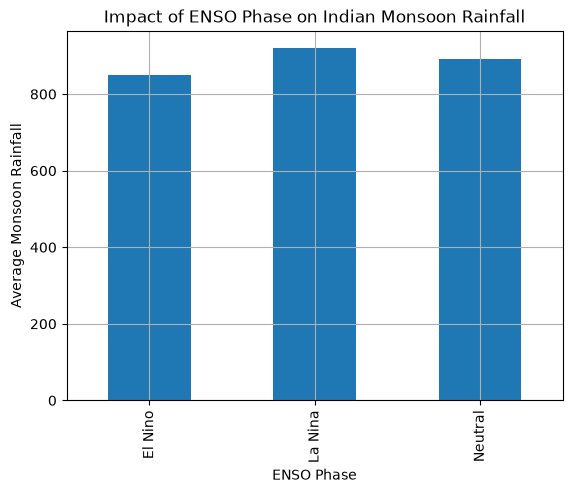

In [106]:
import matplotlib.pyplot as plt

phase_rainfall.plot(
    kind="bar"
)

plt.xlabel("ENSO Phase")
plt.ylabel("Average Monsoon Rainfall")
plt.title("Impact of ENSO Phase on Indian Monsoon Rainfall")

plt.grid(True)
plt.show()

In [107]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,ONI,-43.677809
1,Avg_Temperature,-37.888324


In [108]:
agriculture_clean.head()

,Year,Total_Production,Avg_Yield
0,1997,6.113605e+11,2761.115479
1,1998,7.945267e+11,2711.434640
2,1999,8.630954e+11,2796.409228
3,2000,9.740388e+11,3261.653333
4,2001,9.498138e+11,3313.039293


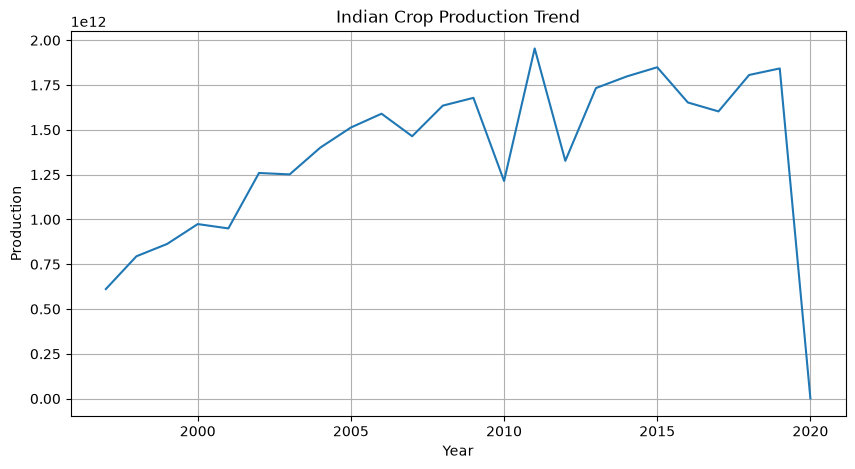

In [109]:
plt.figure(figsize=(10,5))

plt.plot(
    agriculture_clean["Year"],
    agriculture_clean["Total_Production"]
)

plt.xlabel("Year")
plt.ylabel("Production")

plt.title("Indian Crop Production Trend")

plt.grid(True)

plt.show()

In [110]:
water.head()

,Reservoir_name,Basin,Subbasin,Agency_name,Lat,Long,Date,Year,Month,Full_reservoir_level,Live_capacity_FRL,Storage,Level
0,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-01,2024,3,320.04,0.095,0.00810,303.505
1,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-02,2024,3,320.04,0.095,0.00755,303.352
2,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-03,2024,3,320.04,0.095,NaN,NaN
3,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-04,2024,3,320.04,0.095,0.00669,303.093
4,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-05,2024,3,320.04,0.095,0.00621,302.941


In [111]:
merged_ml["ENSO_Phase"].value_counts()

ENSO_Phase
Neutral    35
La Nina    15
El Nino    14
Name: count, dtype: int64

In [112]:
phase_rainfall = (
    merged_ml
    .groupby("ENSO_Phase")["Monsoon_Rainfall"]
    .mean()
)

phase_rainfall

ENSO_Phase
El Nino    850.607143
La Nina    919.360000
Neutral    892.705714
Name: Monsoon_Rainfall, dtype: float64

In [113]:
phase_departure = (
    merged_ml
    .groupby("ENSO_Phase")["Rainfall_Departure"]
    .mean()
)

phase_departure

ENSO_Phase
El Nino   -6.407143
La Nina    3.240000
Neutral   -0.520000
Name: Rainfall_Departure, dtype: float64

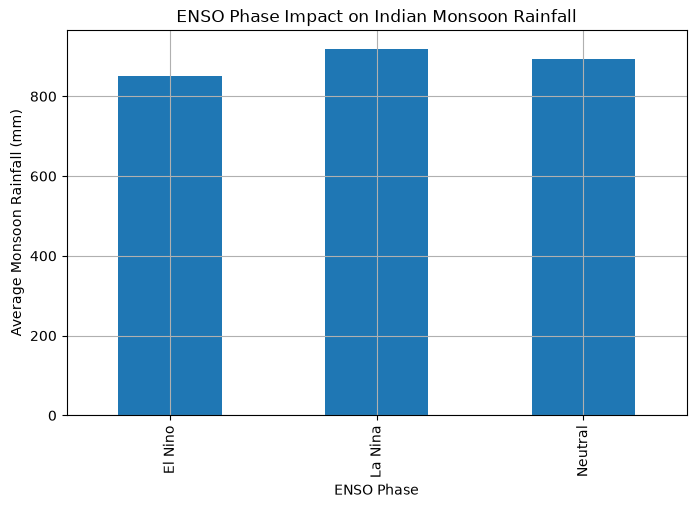

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

phase_rainfall.plot(
    kind="bar"
)

plt.xlabel("ENSO Phase")
plt.ylabel("Average Monsoon Rainfall (mm)")
plt.title("ENSO Phase Impact on Indian Monsoon Rainfall")

plt.grid(True)

plt.show()

In [115]:
el_nino = phase_rainfall["El Nino"]
la_nina = phase_rainfall["La Nina"]

difference = la_nina - el_nino

print("Rainfall difference:", difference, "mm")

Rainfall difference: 68.75285714285712 mm


In [116]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,ONI,-43.677809
1,Avg_Temperature,-37.888324


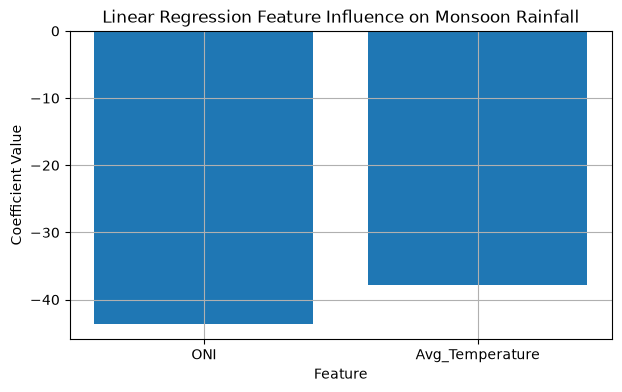

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.title("Linear Regression Feature Influence on Monsoon Rainfall")

plt.grid(True)

plt.show()

In [118]:
import pandas as pd

agriculture_clean = pd.read_csv(
    "../01_Data/Processed/Agriculture/agriculture_cleaned.csv"
)

agriculture_clean.head()

,Year,Total_Production,Avg_Yield
0,1997,6.113605e+11,2761.115479
1,1998,7.945267e+11,2711.434640
2,1999,8.630954e+11,2796.409228
3,2000,9.740388e+11,3261.653333
4,2001,9.498138e+11,3313.039293


In [119]:
print(agriculture_clean.shape)

print(
    agriculture_clean["Year"].min(),
    agriculture_clean["Year"].max()
)

(24, 3)
1997 2020


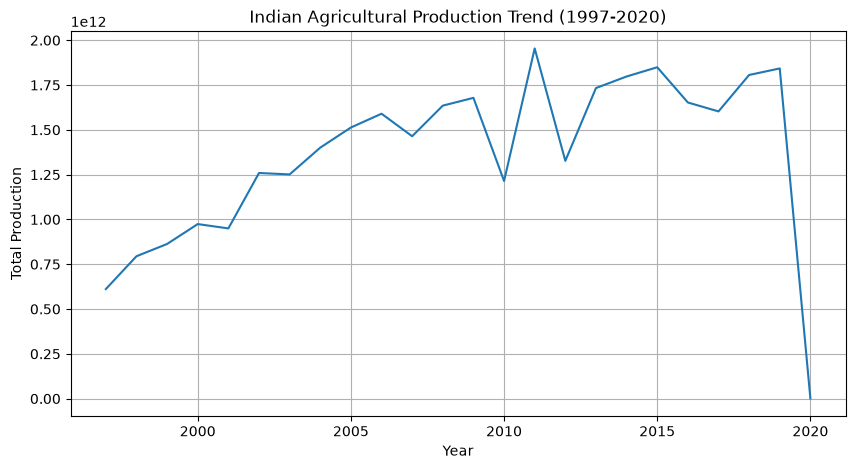

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    agriculture_clean["Year"],
    agriculture_clean["Total_Production"]
)

plt.xlabel("Year")
plt.ylabel("Total Production")

plt.title(
    "Indian Agricultural Production Trend (1997-2020)"
)

plt.grid(True)

plt.show()

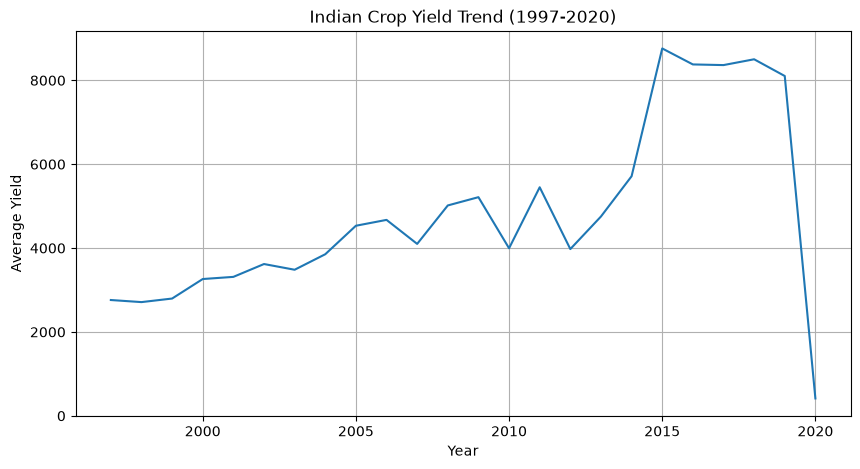

In [121]:
plt.figure(figsize=(10,5))

plt.plot(
    agriculture_clean["Year"],
    agriculture_clean["Avg_Yield"]
)

plt.xlabel("Year")
plt.ylabel("Average Yield")

plt.title(
    "Indian Crop Yield Trend (1997-2020)"
)

plt.grid(True)

plt.show()

In [122]:
agri_climate = pd.merge(
    agriculture_clean,
    merged_ml,
    on="Year",
    how="inner"
)

print(agri_climate.shape)

agri_climate.head()

(17, 8)


,Year,Total_Production,Avg_Yield,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature,ENSO_Phase
0,1997,6.113605e+11,2761.115479,1.166667,927.3,2.2,24.047333,El Nino
1,1998,7.945267e+11,2711.434640,-0.066667,943.1,4.0,24.755417,Neutral
2,1999,8.630954e+11,2796.409228,-1.233333,863.1,-4.4,24.659833,La Nina
3,2000,9.740388e+11,3261.653333,-0.825000,833.7,-7.8,24.498000,La Nina
4,2001,9.498138e+11,3313.039293,-0.300000,821.9,-7.8,24.581917,Neutral


In [123]:
agri_climate[
    [
        "Total_Production",
        "Avg_Yield",
        "Monsoon_Rainfall",
        "ONI"
    ]
].corr()

,Total_Production,Avg_Yield,Monsoon_Rainfall,ONI
Total_Production,1.000000,0.961688,-0.114732,-0.174155
Avg_Yield,0.961688,1.000000,-0.140854,-0.154363
Monsoon_Rainfall,-0.114732,-0.140854,1.000000,-0.244075
ONI,-0.174155,-0.154363,-0.244075,1.000000


In [124]:
def classify_enso(oni):
    if oni >= 0.5:
        return "El Nino"
    elif oni <= -0.5:
        return "La Nina"
    else:
        return "Neutral"


agri_climate["ENSO_Phase"] = (
    agri_climate["ONI"]
    .apply(classify_enso)
)

In [125]:
agri_climate.groupby(
    "ENSO_Phase"
)[
    "Total_Production"
].mean()

ENSO_Phase
El Nino    9.352360e+11
La Nina    1.378096e+12
Neutral    1.345192e+12
Name: Total_Production, dtype: float64

In [126]:
import pandas as pd

water = pd.read_csv(
    "../01_Data/Processed/Water_Resources/water_resources_cleaned.csv"
)

water.head()

,Reservoir_name,Basin,Subbasin,Agency_name,Lat,Long,Date,Year,Month,Full_reservoir_level,Live_capacity_FRL,Storage,Level
0,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-01,2024,3,320.04,0.095,0.00810,303.505
1,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-02,2024,3,320.04,0.095,0.00755,303.352
2,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-03,2024,3,320.04,0.095,NaN,NaN
3,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-04,2024,3,320.04,0.095,0.00669,303.093
4,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-05,2024,3,320.04,0.095,0.00621,302.941


In [127]:
water.info()

<class 'pandas.DataFrame'>
RangeIndex: 3689 entries, 0 to 3688
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Reservoir_name        3689 non-null   str    
 1   Basin                 3689 non-null   str    
 2   Subbasin              3689 non-null   str    
 3   Agency_name           3689 non-null   str    
 4   Lat                   3689 non-null   float64
 5   Long                  3689 non-null   float64
 6   Date                  3689 non-null   str    
 7   Year                  3689 non-null   int64  
 8   Month                 3689 non-null   int64  
 9   Full_reservoir_level  3689 non-null   float64
 10  Live_capacity_FRL     3689 non-null   float64
 11  Storage               2578 non-null   float64
 12  Level                 2596 non-null   float64
dtypes: float64(6), int64(2), str(5)
memory usage: 374.8 KB


In [1]:
water["Storage_Percentage"] = (
    water["Storage"] /
    water["Live_capacity_FRL"]
) * 100

water.head()

NameError: name 'water' is not defined

In [2]:
import pandas as pd

water = pd.read_csv(
    "../01_Data/Raw/Water_Resources/water_resources_raw.csv"
)

water.head()

,Reservoir_name,Basin,Subbasin,Agency_name,Lat,Long,Date,Year,Month,Full_reservoir_level,Live_capacity_FRL,Storage,Level
0,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-01,2024,3,320.04,0.095,0.00810,303.505
1,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-02,2024,3,320.04,0.095,0.00755,303.352
2,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-03,2024,3,320.04,0.095,NaN,NaN
3,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-04,2024,3,320.04,0.095,0.00669,303.093
4,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-05,2024,3,320.04,0.095,0.00621,302.941


In [3]:
water.info()

<class 'pandas.DataFrame'>
RangeIndex: 3689 entries, 0 to 3688
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Reservoir_name        3689 non-null   str    
 1   Basin                 3689 non-null   str    
 2   Subbasin              3689 non-null   str    
 3   Agency_name           3689 non-null   str    
 4   Lat                   3689 non-null   float64
 5   Long                  3689 non-null   float64
 6   Date                  3689 non-null   str    
 7   Year                  3689 non-null   int64  
 8   Month                 3689 non-null   int64  
 9   Full_reservoir_level  3689 non-null   float64
 10  Live_capacity_FRL     3689 non-null   float64
 11  Storage               2578 non-null   float64
 12  Level                 2596 non-null   float64
dtypes: float64(6), int64(2), str(5)
memory usage: 374.8 KB


In [4]:
water["Storage_Percentage"] = (
    water["Storage"] /
    water["Live_capacity_FRL"]
) * 100

water.head()

,Reservoir_name,Basin,Subbasin,Agency_name,Lat,Long,Date,Year,Month,Full_reservoir_level,Live_capacity_FRL,Storage,Level,Storage_Percentage
0,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-01,2024,3,320.04,0.095,0.00810,303.505,8.526316
1,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-02,2024,3,320.04,0.095,0.00755,303.352,7.947368
2,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-03,2024,3,320.04,0.095,NaN,NaN,NaN
3,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-04,2024,3,320.04,0.095,0.00669,303.093,7.042105
4,Aliyar Reservoir,West flowing rivers from Tadri to Kanyakumari ...,Varrar and others,CWC,10.472668,76.974597,2024-03-05,2024,3,320.04,0.095,0.00621,302.941,6.536842


In [5]:
water = water.dropna(
    subset=[
        "Storage",
        "Live_capacity_FRL"
    ]
)

water.shape

(2578, 14)

In [6]:
basin_storage = (
    water
    .groupby("Basin")["Storage_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

basin_storage

Basin
East flowing rivers between Pennar and Kanyakumari Basin            76.559178
Brahmani and Baitarni Basin                                         59.381211
Mahanadi Basin                                                      54.261053
Tapi Basin                                                          51.943946
Narmada Basin                                                       50.315081
Indus (Up to border) Basin                                          50.228993
Ganga Basin                                                         48.261953
Barak and Others Basin                                              47.741109
Godavari Basin                                                      43.100994
West flowing rivers from Tapi to Tadri Basin                        42.749363
Mahi Basin                                                          42.107946
West flowing rivers of Kutch and Saurashtra including Luni Basin    38.010655
West flowing rivers from Tadri to Kanyakumari Basin       

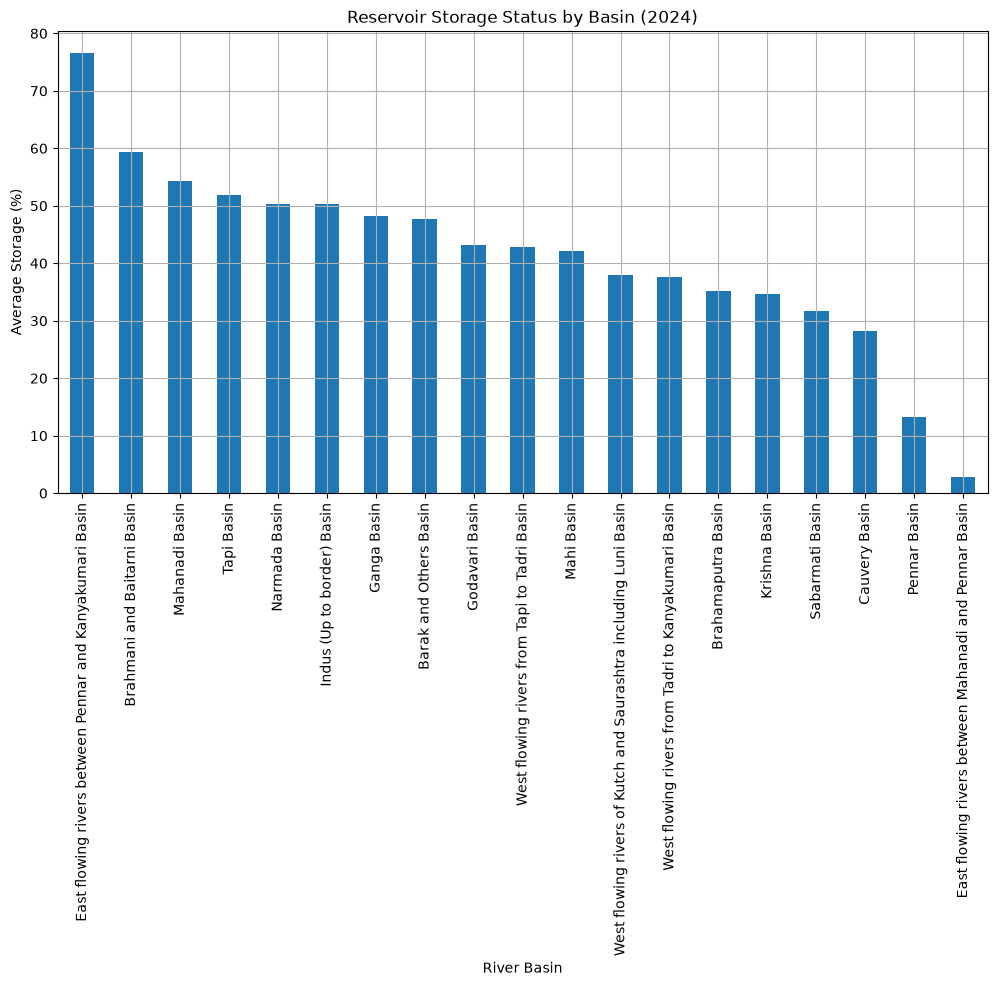

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

basin_storage.plot(
    kind="bar"
)

plt.xlabel("River Basin")
plt.ylabel("Average Storage (%)")
plt.title("Reservoir Storage Status by Basin (2024)")

plt.xticks(rotation=90)

plt.grid(True)

plt.show()

In [8]:
import os

os.makedirs(
    "../05_Results/Water_Analysis",
    exist_ok=True
)

In [9]:
basin_storage.to_csv(
    "../05_Results/Water_Analysis/basin_storage_analysis.csv"
)

print("Water analysis saved!")

Water analysis saved!


In [10]:
import os
import shutil

# Base Results folder
RESULTS = "../05_Results"

# Required structure
folders = [
    "EDA",
    "Model",
    "Agriculture",
    "Water_Analysis"
]

# Create folders
for folder in folders:
    path = os.path.join(RESULTS, folder)
    os.makedirs(path, exist_ok=True)

print("Folders created ✅")


# File movement map
file_map = {
    # EDA
    "correlation_matrix.png": "EDA",
    "rainfall_trend.png": "EDA",
    "oni_rainfall_relation.png": "EDA",
    "enso_phase_rainfall.png": "EDA",

    # Model
    "model_comparison.csv": "Model",
    "actual_vs_predicted.png": "Model",
    "regression_coefficients.png": "Model",

    # Agriculture
    "production_trend.png": "Agriculture",
    "yield_trend.png": "Agriculture",

    # Water
    "basin_storage_analysis.csv": "Water_Analysis"
}


# Search entire Results folder and move files
for root, dirs, files in os.walk(RESULTS):

    for file in files:

        if file in file_map:

            current_path = os.path.join(root, file)
            target_folder = os.path.join(
                RESULTS,
                file_map[file]
            )

            target_path = os.path.join(
                target_folder,
                file
            )

            # avoid moving if already there
            if os.path.abspath(current_path) != os.path.abspath(target_path):

                shutil.move(
                    current_path,
                    target_path
                )

                print(
                    f"Moved: {file} → {file_map[file]}"
                )


print("\nResults organization complete 🚀")

Folders created ✅
Moved: model_comparison.csv → Model

Results organization complete 🚀


In [11]:
for root, dirs, files in os.walk("../05_Results"):
    level = root.replace("../05_Results","").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")
    
    for file in files:
        print(indent + "    " + file)

05_Results/
    Agriculture/
    EDA/
    figures/
    metrics/
    Model/
        model_comparison.csv
    predictions/
    Water_Analysis/
        basin_storage_analysis.csv


In [12]:
import os
import shutil

RESULTS = "../05_Results"

# folders we want to keep
keep_folders = [
    "EDA",
    "Model",
    "Agriculture",
    "Water_Analysis"
]

# folders to remove
remove_folders = [
    "figures",
    "metrics",
    "predictions"
]


for folder in remove_folders:
    path = os.path.join(RESULTS, folder)

    if os.path.exists(path):
        shutil.rmtree(path)
        print("Removed:", folder)


print("\nCleanup complete ✅")

PermissionError: [WinError 5] Access is denied: '../05_Results\\figures'

In [13]:
import os

RESULTS = "../05_Results"

required_folders = [
    "EDA",
    "Model",
    "Agriculture",
    "Water_Analysis"
]

for folder in required_folders:
    path = os.path.join(RESULTS, folder)
    os.makedirs(path, exist_ok=True)
    print("Checked:", folder)

print("Structure ready ✅")

Checked: EDA
Checked: Model
Checked: Agriculture
Checked: Water_Analysis
Structure ready ✅


In [14]:
for root, dirs, files in os.walk("../05_Results"):
    level = root.replace("../05_Results","").count(os.sep)
    indent = "    " * level
    
    print(indent + os.path.basename(root) + "/")
    
    for file in files:
        print(indent + "    " + file)

05_Results/
    Agriculture/
    EDA/
    figures/
    metrics/
    Model/
        model_comparison.csv
    predictions/
    Water_Analysis/
        basin_storage_analysis.csv


In [15]:
import matplotlib.pyplot as plt
import os

os.makedirs("../05_Results/EDA", exist_ok=True)

corr = merged_ml[
    ["ONI", "Monsoon_Rainfall", "Avg_Temperature"]
].corr()

plt.figure(figsize=(6,5))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../05_Results/EDA/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'merged_ml' is not defined

In [16]:
import pandas as pd
import os

merged_ml = pd.read_csv(
    "../01_Data/Processed/Merged/final_ml_dataset.csv"
)

merged_ml.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
0,1950.0,-0.858333,923.2,3.7,23.659333
1,1951.0,0.441667,749.2,-18.7,24.220667
2,1952.0,0.166667,827.8,-8.2,24.365500
3,1953.0,0.708333,983.4,9.8,24.561583
4,1954.0,-0.383333,914.4,3.1,24.167167


In [17]:
merged_ml.shape

(64, 5)

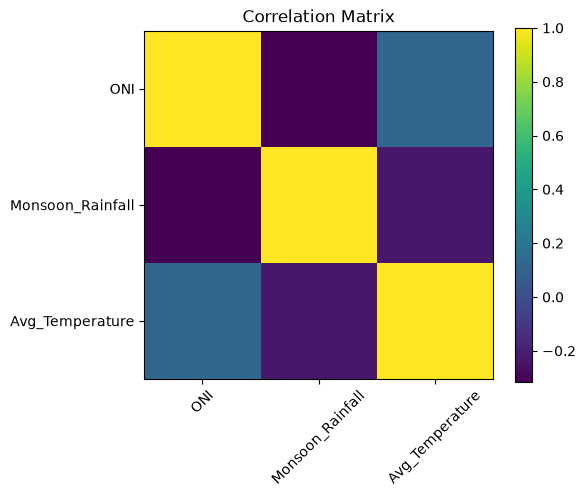

In [18]:
import matplotlib.pyplot as plt

os.makedirs("../05_Results/EDA", exist_ok=True)

corr = merged_ml[
    ["ONI", "Monsoon_Rainfall", "Avg_Temperature"]
].corr()


plt.figure(figsize=(6,5))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../05_Results/EDA/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

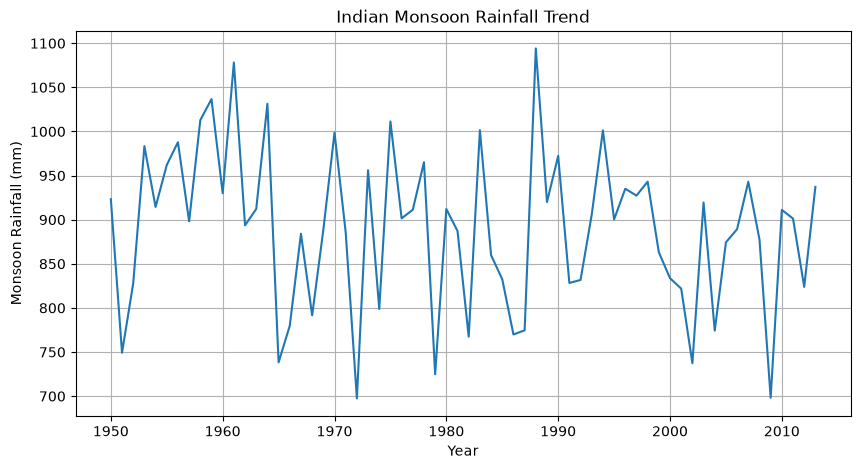

In [19]:
import matplotlib.pyplot as plt
import os

os.makedirs("../05_Results/EDA", exist_ok=True)

plt.figure(figsize=(10,5))

plt.plot(
    merged_ml["Year"],
    merged_ml["Monsoon_Rainfall"]
)

plt.xlabel("Year")
plt.ylabel("Monsoon Rainfall (mm)")

plt.title(
    "Indian Monsoon Rainfall Trend"
)

plt.grid(True)

plt.savefig(
    "../05_Results/EDA/rainfall_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

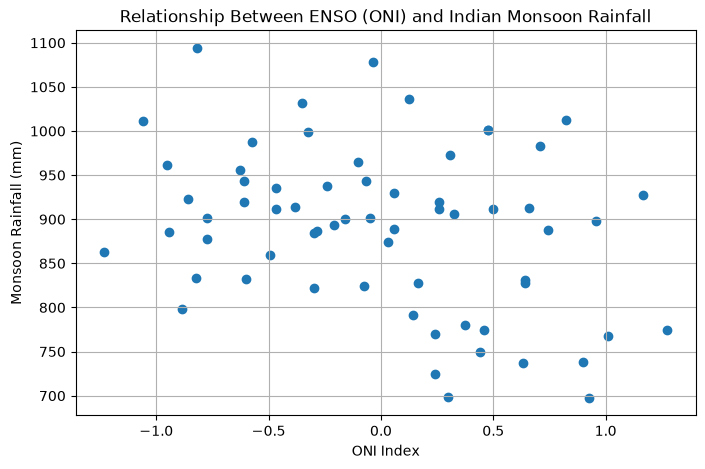

In [20]:
import matplotlib.pyplot as plt
import os

os.makedirs("../05_Results/EDA", exist_ok=True)

plt.figure(figsize=(8,5))

plt.scatter(
    merged_ml["ONI"],
    merged_ml["Monsoon_Rainfall"]
)

plt.xlabel("ONI Index")
plt.ylabel("Monsoon Rainfall (mm)")

plt.title(
    "Relationship Between ENSO (ONI) and Indian Monsoon Rainfall"
)

plt.grid(True)

plt.savefig(
    "../05_Results/EDA/oni_rainfall_relation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
def classify_enso(oni):
    if oni >= 0.5:
        return "El Nino"
    elif oni <= -0.5:
        return "La Nina"
    else:
        return "Neutral"


merged_ml["ENSO_Phase"] = merged_ml["ONI"].apply(classify_enso)


phase_rainfall = (
    merged_ml
    .groupby("ENSO_Phase")["Monsoon_Rainfall"]
    .mean()
)

phase_rainfall

ENSO_Phase
El Nino    850.607143
La Nina    919.360000
Neutral    892.705714
Name: Monsoon_Rainfall, dtype: float64

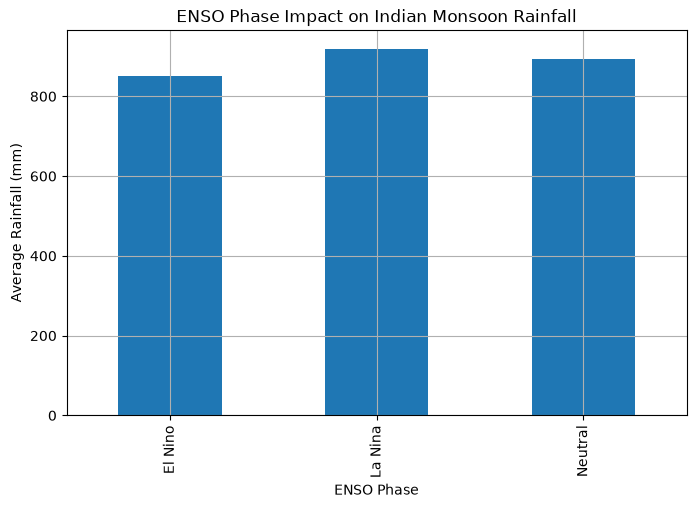

In [22]:
plt.figure(figsize=(8,5))

phase_rainfall.plot(
    kind="bar"
)

plt.xlabel("ENSO Phase")
plt.ylabel("Average Rainfall (mm)")

plt.title(
    "ENSO Phase Impact on Indian Monsoon Rainfall"
)

plt.grid(True)

plt.savefig(
    "../05_Results/EDA/enso_phase_rainfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../05_Results/Model", exist_ok=True)

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")

plt.title(
    "Actual vs Predicted Monsoon Rainfall"
)

plt.grid(True)

plt.savefig(
    "../05_Results/Model/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'y_test' is not defined

<Figure size 800x500 with 0 Axes>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../05_Results/Model", exist_ok=True)

merged_ml = pd.read_csv(
    "../01_Data/Processed/Merged/final_ml_dataset.csv"
)

merged_ml.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
0,1950.0,-0.858333,923.2,3.7,23.659333
1,1951.0,0.441667,749.2,-18.7,24.220667
2,1952.0,0.166667,827.8,-8.2,24.365500
3,1953.0,0.708333,983.4,9.8,24.561583
4,1954.0,-0.383333,914.4,3.1,24.167167


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = merged_ml[
    ["ONI", "Avg_Temperature"]
]

y = merged_ml[
    "Monsoon_Rainfall"
]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

y_pred = lr_model.predict(
    X_test
)

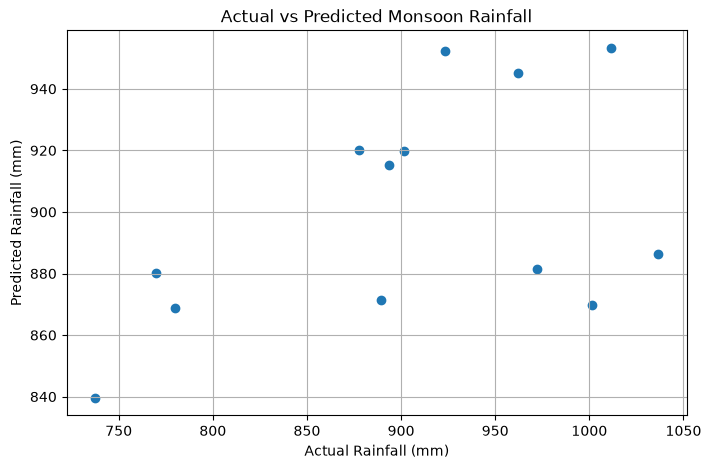

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")

plt.title(
    "Actual vs Predicted Monsoon Rainfall"
)

plt.grid(True)

plt.savefig(
    "../05_Results/Model/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../05_Results/Model", exist_ok=True)


# Create coefficient dataframe
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,ONI,-43.677809
1,Avg_Temperature,-37.888324


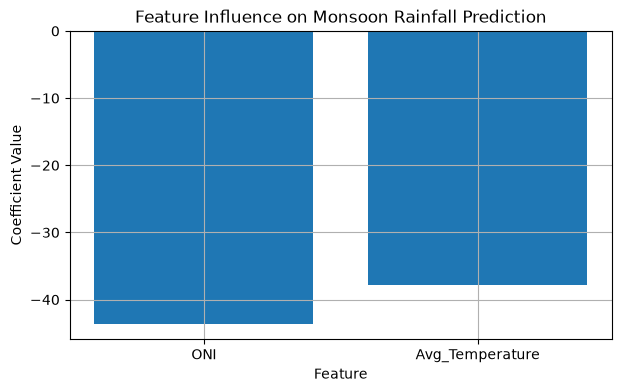

In [30]:
plt.figure(figsize=(7,4))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Feature")
plt.ylabel("Coefficient Value")

plt.title(
    "Feature Influence on Monsoon Rainfall Prediction"
)

plt.grid(True)

plt.savefig(
    "../05_Results/Model/regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../05_Results/Agriculture", exist_ok=True)

agriculture_clean = pd.read_csv(
    "../01_Data/Processed/Agriculture/agriculture_cleaned.csv"
)

agriculture_clean.head()

,Year,Total_Production,Avg_Yield
0,1997,6.113605e+11,2761.115479
1,1998,7.945267e+11,2711.434640
2,1999,8.630954e+11,2796.409228
3,2000,9.740388e+11,3261.653333
4,2001,9.498138e+11,3313.039293


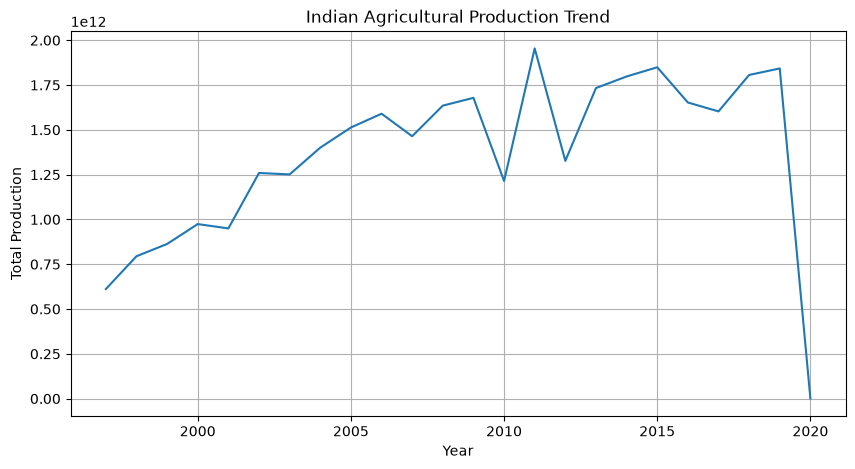

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    agriculture_clean["Year"],
    agriculture_clean["Total_Production"]
)

plt.xlabel("Year")
plt.ylabel("Total Production")

plt.title(
    "Indian Agricultural Production Trend"
)

plt.grid(True)

plt.savefig(
    "../05_Results/Agriculture/production_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

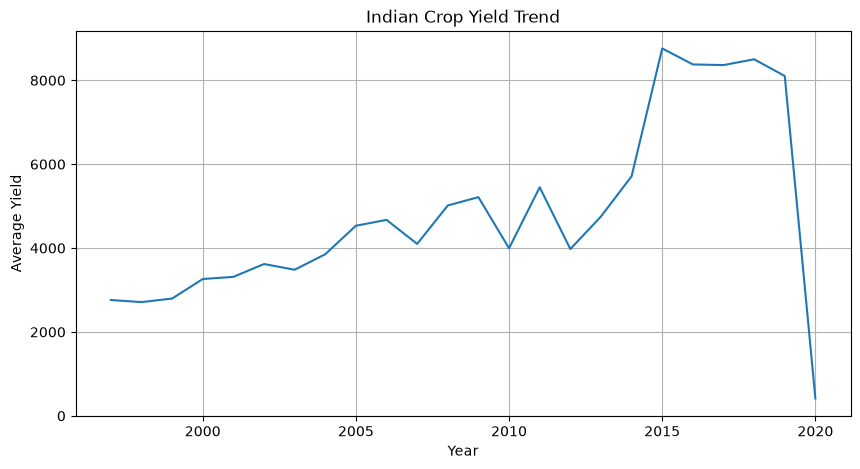

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
    agriculture_clean["Year"],
    agriculture_clean["Avg_Yield"]
)

plt.xlabel("Year")
plt.ylabel("Average Yield")

plt.title(
    "Indian Crop Yield Trend"
)

plt.grid(True)

plt.savefig(
    "../05_Results/Agriculture/yield_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
import os

# Main report folder
report_path = "../06_Report"

# Required folders
folders = [
    "Images",
    "Images/EDA",
    "Images/Model",
    "Images/Agriculture",
    "Images/Water"
]

# Create folders
for folder in folders:
    path = os.path.join(report_path, folder)
    os.makedirs(path, exist_ok=True)
    print("Created:", path)

print("\nReport structure created successfully ✅")

Created: ../06_Report\Images
Created: ../06_Report\Images/EDA
Created: ../06_Report\Images/Model
Created: ../06_Report\Images/Agriculture
Created: ../06_Report\Images/Water

Report structure created successfully ✅


In [35]:
import shutil
import os

source = "../05_Results"
destination = "../06_Report/Images"

# Mapping
copy_map = {
    "EDA": "EDA",
    "Model": "Model",
    "Agriculture": "Agriculture",
    "Water_Analysis": "Water"
}

for src_folder, dest_folder in copy_map.items():

    src_path = os.path.join(source, src_folder)
    dest_path = os.path.join(destination, dest_folder)

    if os.path.exists(src_path):

        for file in os.listdir(src_path):

            if file.endswith((".png", ".jpg", ".csv")):

                shutil.copy(
                    os.path.join(src_path, file),
                    os.path.join(dest_path, file)
                )

                print(
                    f"Copied {file} → {dest_folder}"
                )

print("\nImages copied successfully 🚀")

Copied correlation_matrix.png → EDA
Copied enso_phase_rainfall.png → EDA
Copied oni_rainfall_relation.png → EDA
Copied rainfall_trend.png → EDA
Copied actual_vs_predicted.png → Model
Copied model_comparison.csv → Model
Copied regression_coefficients.png → Model
Copied production_trend.png → Agriculture
Copied yield_trend.png → Agriculture
Copied basin_storage_analysis.csv → Water

Images copied successfully 🚀


In [36]:
for root, dirs, files in os.walk("../06_Report"):
    level = root.replace("../06_Report","").count(os.sep)
    indent = "    " * level
    
    print(indent + os.path.basename(root) + "/")
    
    for file in files:
        print(indent + "    " + file)

06_Report/
    Images/
        Agriculture/
            production_trend.png
            yield_trend.png
        EDA/
            correlation_matrix.png
            enso_phase_rainfall.png
            oni_rainfall_relation.png
            rainfall_trend.png
        Model/
            actual_vs_predicted.png
            model_comparison.csv
            regression_coefficients.png
        Water/
            basin_storage_analysis.csv


In [38]:
from docx import Document
from docx.shared import Pt
import os

# Report location
report_path = "../06_Report"

# Create folder if not present
os.makedirs(report_path, exist_ok=True)

# File path
file_path = os.path.join(
    report_path,
    "Case_Study_Report.docx"
)

# Create document
doc = Document()

# Title
doc.add_heading(
    "AI-Based Analysis and Prediction of El Niño Impact on Indian Monsoon, Agriculture and Water Resources",
    level=1
)


sections = {

"Abstract":
"""
El Niño and La Niña events significantly influence Indian monsoon variability.
This project analyzes ENSO patterns, rainfall, temperature, agriculture and water
resource datasets using exploratory data analysis and machine learning techniques.
The aim is to understand climate impacts and develop predictive insights.
""",

"1. Introduction":
"""
Indian agriculture and water resources are highly dependent on monsoon rainfall.
ENSO (El Niño Southern Oscillation) causes variations in global climate patterns,
affecting rainfall distribution across India.
""",

"2. Objectives":
"""
1. Analyze the relationship between ENSO and Indian monsoon rainfall.
2. Predict rainfall using machine learning models.
3. Study agricultural impact due to rainfall variability.
4. Analyze reservoir conditions and water availability.
5. Provide climate adaptation recommendations.
""",

"3. Dataset Description":
"""
Datasets used:
• ENSO ONI Dataset - Climate indicator
• Indian Rainfall Dataset - Monsoon analysis
• Temperature Dataset - Climate trends
• Agriculture Dataset - Crop production analysis
• Water Resource Dataset - Reservoir analysis
""",

"4. Methodology":
"""
Data Collection
        ↓
Data Cleaning
        ↓
Exploratory Data Analysis
        ↓
Feature Engineering
        ↓
Machine Learning Models
        ↓
Impact Analysis
        ↓
Recommendations
""",

"5. Exploratory Data Analysis":
"""
EDA was performed using correlation analysis, rainfall trends,
ONI-rainfall relationship analysis and ENSO phase comparison.
""",

"6. Machine Learning Model":
"""
Machine learning models were developed to predict monsoon rainfall.
Linear Regression and Random Forest algorithms were evaluated using:
MAE, RMSE and R² score.
""",

"7. Results and Discussion":
"""
The analysis showed that ENSO phases influence Indian monsoon rainfall.
El Niño years generally showed lower rainfall compared to La Niña years.
""",

"8. Agriculture Impact Analysis":
"""
Agricultural production and yield trends were analyzed to understand
the effect of climate variability on crop outcomes.
""",

"9. Water Resource Impact Analysis":
"""
Reservoir storage levels were analyzed across different river basins
to understand water availability conditions.
""",

"10. Recommendations":
"""
• AI-based climate early warning systems
• ENSO-based crop planning
• Improved reservoir management
• Drought preparedness strategies
""",

"11. Conclusion":
"""
This project demonstrates how artificial intelligence and climate datasets
can be used to analyze El Niño impacts on rainfall, agriculture and water resources.
"""
}


# Add sections
for heading, text in sections.items():

    doc.add_heading(
        heading,
        level=2
    )

    paragraph = doc.add_paragraph(text)

    paragraph.style.font.size = Pt(11)


# Save document
doc.save(file_path)

print("Report created successfully ✅")
print(file_path)

Report created successfully ✅
../06_Report\Case_Study_Report.docx


In [30]:
import numpy as np

In [15]:
import os

project_root = r"C:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project"

print("Root exists:", os.path.exists(project_root))
print("Inside root:", os.listdir(project_root))


Root exists: True
Inside root: ['01_Data', '02_Literature_Review', '03_Notebooks', '04_Models', '05_Results', '06_Report', '07_Presentation']


In [16]:
import os

data_path = r"C:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\01_Data"

print(os.listdir(data_path))

['External', 'Processed', 'Raw']


In [17]:
import os

raw_path = r"C:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\01_Data\Raw"

print(os.listdir(raw_path))

['Agriculture', 'ENSO_ONI', 'Rainfall', 'Temperature', 'Water_Resources']


In [18]:
import os

oni_path = r"C:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\01_Data\Raw\ENSO_ONI"

print(os.listdir(oni_path))

['metadata', 'oni_raw.xlsx']


In [20]:
import os

oni_path = r"C:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\01_Data\Raw\ENSO_ONI\oni_raw.xlsx"

print("Exists:", os.path.exists(oni_path))


Exists: True


In [2]:
import os

print(os.path.getsize(oni_path))

13769


In [3]:
import os

oni_path = r"C:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\01_Data\Raw\ENSO_ONI\oni_raw.xlsx"

print(os.path.getsize(oni_path))

13769


In [4]:
import pandas as pd

try:
    xls = pd.ExcelFile(oni_path, engine="openpyxl")
    print(xls.sheet_names)
except Exception as e:
    print("ERROR:", e)

ERROR: [Errno 13] Permission denied: 'C:\\Users\\anand\\OneDrive\\Desktop\\ElNino_Hybrid_AI_Project\\01_Data\\Raw\\ENSO_ONI\\oni_raw.xlsx'


In [1]:
import pandas as pd

oni_path = r"C:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\01_Data\Raw\ENSO_ONI\oni_raw.xlsx"

df_oni = pd.read_excel(oni_path, engine="openpyxl")

df_oni.head()

,Year,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
0,1950.0,-1.5,-1.3,-1.2,-1.2,-1.1,-0.9,-0.5,-0.4,-0.4,-0.4,-0.6,-0.8
1,1951.0,-0.8,-0.5,-0.2,0.2,0.4,0.6,0.7,0.9,1,1.2,1,0.8
2,1952.0,0.5,0.4,0.3,0.3,0.2,0,-0.1,0,0.2,0.1,0,0.1
3,1953.0,0.4,0.6,0.6,0.7,0.8,0.8,0.7,0.7,0.8,0.8,0.8,0.8
4,1954.0,0.8,0.5,0,-0.4,-0.5,-0.5,-0.6,-0.8,-0.9,-0.8,-0.7,-0.7


In [2]:

df_oni.shape

(78, 13)

In [3]:
df_oni.columns

Index(['Year', 'DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO',
       'SON', 'OND', 'NDJ'],
      dtype='str')

In [4]:
df_melt = df_oni.melt(id_vars=["Year"], 
                      var_name="Season", 
                      value_name="ONI")

df_melt.head()

,Year,Season,ONI
0,1950.0,DJF,-1.5
1,1951.0,DJF,-0.8
2,1952.0,DJF,0.5
3,1953.0,DJF,0.4
4,1954.0,DJF,0.8


In [6]:

df_melt = df_melt.sort_values(["Year", "Season"])
df_melt.head()

,Year,Season,ONI
312,1950.0,AMJ,-1.1
624,1950.0,ASO,-0.4
0,1950.0,DJF,-1.5
156,1950.0,FMA,-1.2
546,1950.0,JAS,-0.4


In [40]:
# Phase 2: Exploratory Data Analysis
import pandas as pd
import matplotlib.pyplot as plt

oni = pd.read_csv("../01_Data/Processed/ENSO_ONI oni_cleaned.csv")

oni.head()

FileNotFoundError: [Errno 2] No such file or directory: '../01_Data/Processed/ENSO_ONI oni_cleaned.csv'

In [41]:
import os

print(os.getcwd())

c:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\03_Notebooks


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

oni = pd.read_csv(
    r"../01_Data/Processed/ENSO_ONI oni_cleaned.csv"
)

oni.head()

FileNotFoundError: [Errno 2] No such file or directory: '../01_Data/Processed/ENSO_ONI oni_cleaned.csv'

In [43]:
import os

project_path = r"C:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project"

for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)
    indent = "    " * level
    
    print(indent + "📁 " + os.path.basename(root) + "/")
    
    for file in files:
        print(indent + "    📄 " + file)

📁 ElNino_Hybrid_AI_Project/
    📁 01_Data/
        📁 External/
            📁 Data_Dictionaries/
            📁 References/
            📁 Source_Documents/
        📁 Processed/
            📁 Agriculture/
                📄 agriculture_cleaned.csv
            📁 ENSO_ONI/
                📄 oni_cleaned.csv
            📁 Merged/
                📄 final_ml_dataset.csv
            📁 Rainfall/
                📄 rainfall_cleaned.csv
            📁 Temperature/
                📄 temperature_cleaned.csv
            📁 Water_Resources/
                📄 water_resources_cleaned.csv
        📁 Raw/
            📁 Agriculture/
                📄 agriculture_raw.csv
                📁 metadata/
            📁 ENSO_ONI/
                📄 oni_raw.xlsx
                📁 metadata/
            📁 Rainfall/
                📄 india_rainfall_raw.csv
                📁 metadata/
            📁 Temperature/
                📄 temperature_raw.csv
                📁 metadata/
            📁 Water_Resources/
                📄 wa